
Routing Table for RouterA:
Destination Network  Next Hop  
------------------------------
192.168.1.0/24       Local     
192.168.2.0/24       RouterC   
192.168.3.0/24       RouterC   
192.168.5.0/24       RouterC   
192.168.0.0/16       RouterC   
------------------------------

Routing Table for RouterB:
Destination Network  Next Hop  
------------------------------
192.168.1.0/24       RouterC   
192.168.2.0/24       Local     
192.168.3.0/24       RouterC   
192.168.5.0/24       RouterD   
192.168.0.0/16       RouterD   
------------------------------

Routing Table for RouterC:
Destination Network  Next Hop  
------------------------------
192.168.1.0/24       RouterA   
192.168.2.0/24       RouterB   
192.168.3.0/24       Local     
192.168.5.0/24       RouterB   
192.168.0.0/16       RouterB   
------------------------------

Routing Table for RouterD:
Destination Network  Next Hop  
------------------------------
192.168.1.0/24       RouterB   
192.168.2.0/24       RouterB   

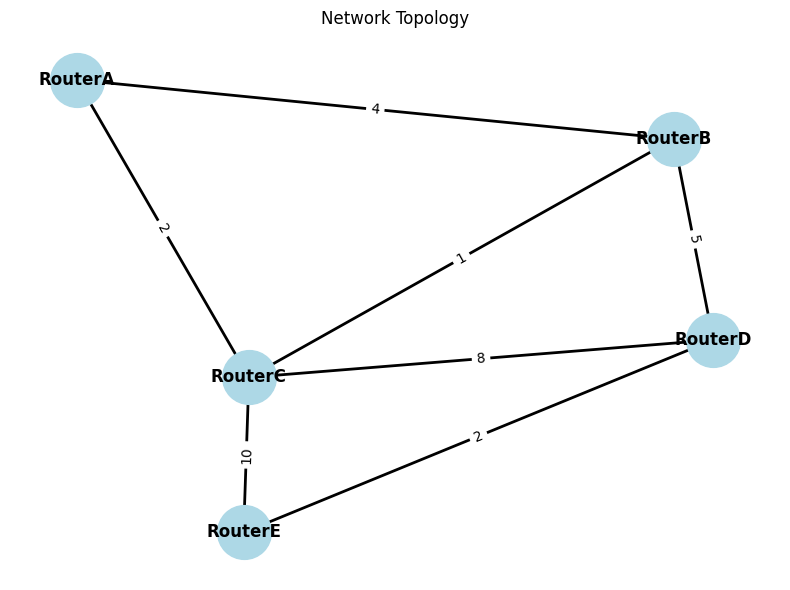

Network topology has been saved as network_topology.png.
Trie for RouterA has been saved as trie_RouterA.png
Trie for RouterB has been saved as trie_RouterB.png
Trie for RouterC has been saved as trie_RouterC.png
Trie for RouterD has been saved as trie_RouterD.png
Trie for RouterE has been saved as trie_RouterE.png
Packet Forwarding Simulation: From RouterA to 192.168.5.10
Packet forwarded from RouterA to RouterC
Packet forwarded from RouterC to RouterB
Packet forwarded from RouterB to RouterD

Packet reached destination at RouterD's local network (192.168.5.0/24)
Path taken: RouterA -> RouterC -> RouterB -> RouterD
Path taken: RouterA -> RouterC -> RouterB -> RouterD


In [8]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt
from graphviz import Digraph
import ipaddress

class TrieNode:
    def __init__(self):
        self.children = {}
        self.next_hop = None

class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, ip_prefix, next_hop):
        node = self.root
        binary_ip, prefix_length = self.ip_prefix_to_binary(ip_prefix)
        for bit in binary_ip[:prefix_length]:
            if bit not in node.children:
                node.children[bit] = TrieNode()
            node = node.children[bit]
        node.next_hop = next_hop

    def search(self, ip_address):
        """
        Lookup the next hop for the given IP address using the longest prefix match.
        """
        node = self.root
        longest_match = None

        binary_ip = self.ip_to_binary(ip_address)

        for bit in binary_ip:
            if bit in node.children:
                node = node.children[bit]
                if node.next_hop:
                    longest_match = node.next_hop  # Update for longer match
            else:
                break

        return longest_match

    def ip_to_binary(self, ip):
        return ''.join([format(int(octet), '08b') for octet in ip.split('.')])

    def ip_prefix_to_binary(self, ip_prefix):
        network = ipaddress.ip_network(ip_prefix)
        binary_ip = self.ip_to_binary(str(network.network_address))
        return binary_ip, network.prefixlen

    def visualize_trie(self, router_name, filename):
        dot = Digraph(comment=f'Trie for {router_name}')
        dot.node('0', 'Root')

        def add_edges(node, node_id):
            for bit, child in node.children.items():
                child_id = node_id + bit
                label = bit
                if child.next_hop:
                    label += f"\n({child.next_hop})"
                dot.node(child_id, label)
                dot.edge(node_id, child_id, label=bit)
                add_edges(child, child_id)

        add_edges(self.root, '0')
        dot.render(filename, view=False, format='png')
        print(f"Trie for {router_name} has been saved as {filename}.png")

class Router:
    def __init__(self, name, local_network):
        self.name = name
        self.local_network = local_network  # e.g., '192.168.1.0/24'
        self.connections = {}  # neighbor_name: cost
        self.trie = Trie()
        self.routing_table = {}  # destination_network: next_hop

    def add_connection(self, neighbor, cost):
        self.connections[neighbor] = cost

    def add_route(self, destination_network, next_hop):
        self.trie.insert(destination_network, next_hop)
        self.routing_table[destination_network] = next_hop

    def display_routing_table(self):
        print(f"\nRouting Table for {self.name}:")
        print(f"{'Destination Network':<20} {'Next Hop':<10}")
        print("-" * 30)
        for dest_net, next_hop in self.routing_table.items():
            print(f"{dest_net:<20} {next_hop:<10}")
        print("-" * 30)

    def visualize_trie(self):
        filename = f"trie_{self.name}"
        self.trie.visualize_trie(self.name, filename)

    def get_next_hop(self, destination_ip):
        return self.trie.search(destination_ip)

class Network:
    def __init__(self):
        self.routers = {}  # name: Router instance

    def add_router(self, name, local_network):
        self.routers[name] = Router(name, local_network)

    def connect_routers(self, router1, router2, cost):
        self.routers[router1].add_connection(router2, cost)
        self.routers[router2].add_connection(router1, cost)

    def predefined_topology(self):
        """
        Define a fixed network topology as per the methodology.
        """
        # Adding routers with their local networks
        self.add_router('RouterA', '192.168.1.0/24')
        self.add_router('RouterB', '192.168.2.0/24')
        self.add_router('RouterC', '192.168.3.0/24')
        self.add_router('RouterD', '192.168.5.0/24')
        self.add_router('RouterE', '192.168.0.0/16')

        # Defining connections and their costs
        connections = [
            ('RouterA', 'RouterB', 4),
            ('RouterA', 'RouterC', 2),
            ('RouterB', 'RouterC', 1),
            ('RouterB', 'RouterD', 5),
            ('RouterC', 'RouterD', 8),
            ('RouterC', 'RouterE', 10),
            ('RouterD', 'RouterE', 2)
        ]

        for r1, r2, cost in connections:
            self.connect_routers(r1, r2, cost)

    def dijkstra(self, start):
        """
        Implements Dijkstra's algorithm to find shortest paths from start router.
        """
        distances = {router: float('inf') for router in self.routers}
        previous = {router: None for router in self.routers}
        distances[start] = 0
        heap = [(0, start)]

        while heap:
            current_distance, current_router = heapq.heappop(heap)

            if current_distance > distances[current_router]:
                continue

            for neighbor, cost in self.routers[current_router].connections.items():
                distance = current_distance + cost
                if distance < distances[neighbor]:
                    distances[neighbor] = distance
                    previous[neighbor] = current_router
                    heapq.heappush(heap, (distance, neighbor))

        return distances, previous

    def compute_routing_tables(self):
        """
        Computes routing tables for all routers using Dijkstra's algorithm.
        """
        for router in self.routers:
            distances, previous = self.dijkstra(router)
            for dest_router in self.routers:
                if router == dest_router:
                    # Route to local network is 'Local'
                    self.routers[router].add_route(self.routers[router].local_network, 'Local')
                elif distances[dest_router] != float('inf'):
                    # Determine next hop
                    next_hop = dest_router
                    while previous[next_hop] != router and previous[next_hop] is not None:
                        next_hop = previous[next_hop]
                    self.routers[router].add_route(self.routers[dest_router].local_network, next_hop)

    def display_routing_tables(self):
        """
        Displays routing tables for all routers.
        """
        for router in self.routers.values():
            router.display_routing_table()

    def visualize_network_topology(self, filename='network_topology.png'):
        """
        Visualizes the network topology using networkx and matplotlib.
        """
        G = nx.Graph()
        for router, r_instance in self.routers.items():
            G.add_node(router)
            for neighbor, cost in r_instance.connections.items():
                G.add_edge(router, neighbor, weight=cost)

        pos = nx.spring_layout(G, seed=42)  # Consistent layout
        plt.figure(figsize=(8, 6))
        nx.draw_networkx_nodes(G, pos, node_size=1500, node_color='lightblue')
        nx.draw_networkx_edges(G, pos, width=2)
        nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

        # Draw edge labels (weights)
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

        plt.title("Network Topology")
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(filename)
        plt.show()
        print(f"Network topology has been saved as {filename}.")

    def visualize_tries(self):
        """
        Visualizes the Tries for all routers.
        """
        for router in self.routers.values():
            router.visualize_trie()

    def simulate_packet_forwarding(self, source_router, destination_ip):
        """
        Simulates packet forwarding from source_router to destination_ip using Tries for LPM.
        """
        path = []
        current_router = source_router

        while True:
            path.append(current_router)
            current_hop = self.routers[current_router].get_next_hop(destination_ip)

            if current_hop == 'Local':
                print(f"\nPacket reached destination at {current_router}'s local network ({self.routers[current_router].local_network})")
                print(f"Path taken: {' -> '.join(path)}")
                break
            elif current_hop is None:
                print(f"\nNo route found for IP {destination_ip} at {current_router}. Packet dropped.")
                print(f"Path taken: {' -> '.join(path)}")
                break
            elif current_hop in path:
                print("Routing loop detected!")
                print(f"Path taken before loop: {' -> '.join(path)}")
                break
            else:
                print(f"Packet forwarded from {current_router} to {current_hop}")
                current_router = current_hop

        return path

def main():
    # Initialize network
    network = Network()
    network.predefined_topology()

    # Compute routing tables
    network.compute_routing_tables()

    # Display routing tables
    network.display_routing_tables()

    # Visualize network topology
    network.visualize_network_topology()

    # Visualize Tries
    network.visualize_tries()

    # Simulate packet forwarding
    # Example: Forward a packet from RouterA to RouterE's local network
    destination_ip = '192.168.5.10'  # IP within RouterE's local network
    source_router = 'RouterA'
    print(f"Packet Forwarding Simulation: From {source_router} to {destination_ip}")
    path_taken = network.simulate_packet_forwarding(source_router, destination_ip)
    print(f"Path taken: {' -> '.join(path_taken)}")

if __name__ == "__main__":
    main()
